# Text classification - decoder-only models

## Librerias y datos

In [ ]:
# !pip install -q -U bitsandbytes unsloth evaluate

In [ ]:
# !tar -xf 20news-18828.tar

In [ ]:
import os
from tqdm import tqdm
from datasets import Dataset
import regex as re


In [ ]:
CWD = os.getcwd()

NEWSGROUPS20 = os.path.join(CWD, '20news-18828')

assert os.path.exists(NEWSGROUPS20), f'El directorio {NEWSGROUPS20} no existe'

NEWSGROUPS = os.listdir(NEWSGROUPS20)

print(f'Se encontraron {len(NEWSGROUPS)} newsgroups: {NEWSGROUPS}')

Se encontraron 20 newsgroups: ['alt.atheism', 'rec.motorcycles', 'rec.sport.baseball', 'rec.autos', 'comp.os.ms-windows.misc', 'talk.religion.misc', 'sci.crypt', 'talk.politics.guns', 'misc.forsale', 'sci.electronics', 'soc.religion.christian', 'rec.sport.hockey', 'comp.sys.mac.hardware', 'sci.med', 'comp.windows.x', 'talk.politics.misc', 'comp.graphics', 'sci.space', 'talk.politics.mideast', 'comp.sys.ibm.pc.hardware']


## Dataset

In [ ]:
def load_file_content(filepath:str) -> str:
  """ Carga el contenido de ´filepath´ """

  with open(filepath, 'r',errors='ignore') as f:
    return f.read()

In [ ]:
newsgroups = {'text':[],
              'label':[],
              'filename':[]}

for newsgroup in NEWSGROUPS:
  nesgroup_dir = os.path.join(NEWSGROUPS20, newsgroup)

  for file in os.listdir(nesgroup_dir):
    filepath = os.path.join(nesgroup_dir, file)

    newsgroups['text'].append(load_file_content(filepath))
    newsgroups['label'].append( os.path.basename(os.path.dirname(filepath)) )
    newsgroups['filename'].append(filepath)

newsgroups = Dataset.from_dict(newsgroups)
newsgroups

Dataset({
    features: ['text', 'label', 'filename'],
    num_rows: 18828
})

In [ ]:
#map
def truncate_text_column(example,text_label:str='text'):
  example[text_label] = example[text_label][:3050]

  return example

newsgroups = newsgroups.map(truncate_text_column)
newsgroups

Map:   0%|          | 0/18828 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'filename'],
    num_rows: 18828
})

## Modelo

In [ ]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length = 20480,
    dtype = None, # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
    load_in_4bit = True,
    # token = "hf_...", # use one if using gated models like meta-llama/Llama-2-7b-hf
)

FastLanguageModel.for_inference(model) # Enable native 2x faster inference

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.11.6: Fast Llama patching. Transformers: 4.57.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128004)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm):

## Prompt

In [ ]:
prompt_template = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

In [ ]:
instruction = (
"""Newsgroups are discussion forums that were part of Usenet, a decentralized network created in 1980. They functioned somewhat like early message boards or modern Reddit communities. Key points:

Topic-based: Newsgroups were organized into hierarchies (e.g., comp., sci., rec., alt.).

Text-based discussions: Users posted “articles” that others could read and reply to.

Here are short descriptions of some of them.

alt.atheism
Discussion of atheism, skepticism, secular philosophy, and related social issues.

comp.graphics
Topics in computer graphics, including rendering, image processing, algorithms, and graphics hardware.

comp.os.ms-windows.misc
General discussion about Microsoft Windows operating systems that doesn’t fit into more specific Windows subgroups.

comp.sys.ibm.pc.hardware
Technical talk about IBM-compatible PC hardware, components, troubleshooting, and upgrades.

comp.sys.mac.hardware
Hardware-related discussion for Apple Macintosh computers, including repairs, peripherals, and performance issues.

comp.windows.x
Information and technical discussion about the X Window System, its configuration, clients, servers, and development.

misc.forsale
A general marketplace newsgroup for buying, selling, and trading items of all kinds.

rec.autos
Discussion of cars, driving, automotive technology, and vehicle maintenance.

rec.motorcycles
Conversations about motorcycles, riding, maintenance, gear, and motorcycling culture.

rec.sport.baseball
News and discussion about baseball teams, players, games, statistics, and fandom.

rec.sport.hockey
Hockey-related discussion, including teams, leagues, games, players, and news.

sci.crypt
Cryptography theory and practice, including algorithms, protocols, security analysis, and policy issues.

sci.electronics
Electronics design, circuits, components, troubleshooting, and hobbyist or professional electronic engineering topics.

sci.med
Medical and health-related discussion, including research, clinical questions, and general medical information.

sci.space
Space science, astronomy, spacecraft, missions, and space exploration news and discussion.

soc.religion.christian
Moderated discussions of Christianity, theology, scripture, practice, and Christian perspectives.

talk.politics.guns
Debate and discussion of gun policy, firearm laws, rights, technology, and related political issues.

talk.politics.mideast
Political discussion specifically focused on Middle Eastern countries, policies, conflicts, and diplomacy.

talk.politics.misc
General political debate and discussion on topics not covered by more focused political newsgroups.

talk.religion.misc
Discussions and debates about religion in general, covering beliefs, philosophies, practices, and comparative topics.

Classify the post into one of these 20 newsgroups:

alt.atheism
comp.graphics
comp.os.ms-windows.misc
comp.sys.ibm.pc.hardware
comp.sys.mac.hardware
comp.windows.x
misc.forsale
rec.autos
rec.motorcycles
rec.sport.baseball
rec.sport.hockey
sci.crypt
sci.electronics
sci.med
sci.space
soc.religion.christian
talk.politics.guns
talk.politics.mideast
talk.politics.misc
talk.religion.misc""")

context = (
"""
post:
{post}
""")

## Generation

## Batch size = 1

In [ ]:
responses = []
PROCESS_SAMPLES = 1600
for sample in tqdm(newsgroups.shuffle(seed=67).select(range(PROCESS_SAMPLES))):
  post = sample['text']
  label = sample['label']

  inputs = tokenizer(
  [
      prompt_template.format(
          instruction, # instruction
          context.format(post=post), # input
          "", # output - leave this blank for generation!
      )
  ], return_tensors = "pt").to("cuda")

  outputs = model.generate(**inputs, max_new_tokens = 128)#, use_cache = True)

  response = tokenizer.batch_decode(outputs)[0].split('Response:\n')[-1]

  responses.append((response,label))

100%|██████████| 1600/1600 [3:35:55<00:00,  8.10s/it]


In [ ]:
#persist responses in disk
import pickle
with open('responses.pkl', 'wb') as f:
  pickle.dump(responses, f)

## Process responses

In [ ]:
def get_newsgroups_references(response:str) -> list[str]:
  """get first newsgroups references"""

  pattern = r'|'.join(NEWSGROUPS)

  match = re.search(pattern, response)
  if match:
      return match.group()
  else:
    return ''

### Confusion matrix

In [ ]:
preds = [ get_newsgroups_references(r[0]) for r in responses ]
labels = [ r[1] for r in responses ]

In [ ]:
assert len(preds) == len(labels)

In [ ]:
labels[0], preds[0]

('talk.politics.mideast', 'soc.religion.christian')

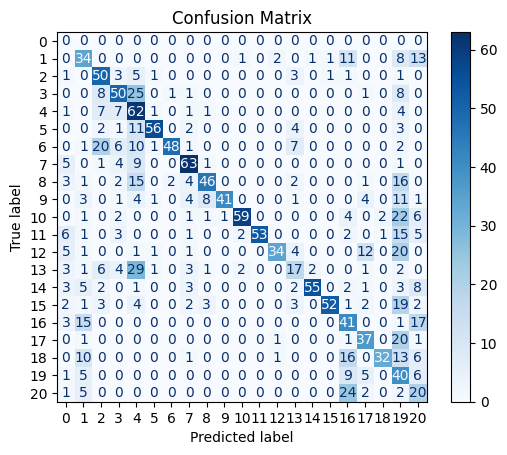

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(labels, preds)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
list(enumerate(sorted(NEWSGROUPS)))

[(0, 'alt.atheism'),
 (1, 'comp.graphics'),
 (2, 'comp.os.ms-windows.misc'),
 (3, 'comp.sys.ibm.pc.hardware'),
 (4, 'comp.sys.mac.hardware'),
 (5, 'comp.windows.x'),
 (6, 'misc.forsale'),
 (7, 'rec.autos'),
 (8, 'rec.motorcycles'),
 (9, 'rec.sport.baseball'),
 (10, 'rec.sport.hockey'),
 (11, 'sci.crypt'),
 (12, 'sci.electronics'),
 (13, 'sci.med'),
 (14, 'sci.space'),
 (15, 'soc.religion.christian'),
 (16, 'talk.politics.guns'),
 (17, 'talk.politics.mideast'),
 (18, 'talk.politics.misc'),
 (19, 'talk.religion.misc')]

### accuracy

In [ ]:
references = list(map(lambda r: (get_newsgroups_references(r[0]),r[1]), responses))

In [ ]:
from functools import reduce

correct = reduce(lambda acc, x: acc + 1 if x[0]==x[1] else acc, references, 0)
print(correct/PROCESS_SAMPLES, correct)

0.55625 890


40/100 (40%)

110/200(55%)

324/600(54%) 1h:24m

545/1000 (54.5%) 2h:20m
890/1600 (55.6%) 3h:36m

### accuracy, precision, recall and f1 score

In [ ]:
import evaluate

# metricas de evaluación
accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

label2int = {label:i for i,label in enumerate(NEWSGROUPS + [''])}
int2label = {i:label for i,label in enumerate(NEWSGROUPS + [''])}

labels_id = [label2int[l] for l in labels]
preds_id = [label2int[p] for p in preds]

results = {

  'precision (macro)' : precision.compute(predictions=preds_id, references=labels_id, average='macro')['precision'],
  'precision (micro)' : precision.compute(predictions=preds_id, references=labels_id, average='micro')['precision'],

  'recall (macro)' : recall.compute(predictions=preds_id, references=labels_id, average='macro')['recall'],
  'recall (micro)' : recall.compute(predictions=preds_id, references=labels_id, average='micro')['recall'],

  'f1 (macro)' : f1.compute(predictions=preds_id, references=labels_id, average='macro')['f1'],
  'f1 (micro)' : f1.compute(predictions=preds_id, references=labels_id, average='micro')['f1'],

  'accuracy' : accuracy.compute(predictions=preds_id, references=labels_id)['accuracy'],
}

results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'precision (macro)': 0.6447315886116667,
 'precision (micro)': 0.55625,
 'recall (macro)': 0.5268110853262943,
 'recall (micro)': 0.55625,
 'f1 (macro)': 0.5484047929752668,
 'f1 (micro)': 0.55625,
 'accuracy': 0.55625}

# Cosas que se intentaron
## Generation

In [ ]:
# def promptize_fn(x):
#   return prompt_template.format(instruction, context.format(post=x),"")

# def tokenize_fn(sample):
#   return tokenizer(sample,padding=True, max_length=30000,return_tensors='pt').to("cuda")

#   return sample

In [ ]:
# responses = []
# PROCESS_SAMPLES = 1000


# for batch in tqdm(newsgroups.shuffle(seed=67).select(range(PROCESS_SAMPLES)).batch(4)):
#   processed_batch = list(map(promptize_fn, batch['text']))
#   processed_batch = tokenize_fn(processed_batch)
#   outputs = model.generate(**processed_batch, max_new_tokens = 128, use_cache = True)

#   response = list(map(lambda x: (x[1].split('Response:\n')[-1], batch['label'][x[0]]), enumerate(tokenizer.batch_decode(outputs))))

#   responses.extend(response)

Al intentar aumentar el batch de generacion, hay textos largos de +18k tokens lo que hace que la memoria estalle. para eso, habria que separar los textos largos y procesarlos individualmente y generar por lotes el resto. Otra opción es limitar los textos a cierto valor. Se toma la longitud maxima del 90% mas corto (3050 caracteres).

En gpu dedicada el procesamiento de batch size 1 disminuye de 8 a 4 segundos y con batch de 16 disminuye a un segundo cada prompt, con 8 a casi 1.5s. Por la variedad de longitud de los textos, se limita a 3050 caracteres en formato string y a 1500 tokens en la etapa de tokenizacion para balancear el consumo de memoria y realizar un proceso de generacion mas estable. Por hacer, trucar a 1500 tokens debido a que la plantilla de generacion contiene la palabra Response se debe procesar los tensores y concatenar con la respuesta.

Se logra ahorro de tiempo con batch de 8, con menos el tiempo tiende a ser igual que batch = 1. En colab es dificil mantener batch de 8 por la capacidad de la memoria.

## Process Responses

Identificar todas las referencias a newsgroups en cada respuesta. Se identificaron dos tipos de respuesta del modelo. En la primera, el modelo está seguro de la respuesta y la respuesta es "the newsgroup for this post would be: ...." Sin embargo, el modelo no genera el mismo texto para todas las veces, a veces cambia ligeramente como 'The post would be classified as: ...' Por lo que no se puede aplicar regex. El segundo tipo de respuesta no esta seguro y argumenta en cuales newsgroups seria buena eleccion pero no da respuesta final. Por estas razones se cambió de estrategia a encontrar la primera referencia a un newsgroup en la respuesta.

In [ ]:
# def get_newsgroups_references(response:str) -> list[str]:
#   """get all newsgroups references"""
#   result = []
#   for newsgroup in NEWSGROUPS:
#     if newsgroup.lower() in response.lower():
#       result.append(newsgroup)
#   return result